- DPO-PYTHONRHB-1
- Чижов А.С.
- [Модуль 20, урок 10 (Задание 9.11. Модуль 13 (HW-01))](https://apps.skillfactory.ru/learning/course/course-v1:skillfactory+PYTHONRHB+2025/block-v1:skillfactory+PYTHONRHB+2025+type@sequential+block@d6afe33294e44fad817051b9a357dfbb/block-v1:skillfactory+PYTHONRHB+2025+type@vertical+block@93148be63da54710a2b6882a997dd61c)

Описание данных


Перед выполнением задания обязательно подумайте, какие признаки в данных являются числовыми, а какие — категориальными. Это поможет вам построить правильный график (ещё раз взгляните на схему выбора графика).


Столбцы таблицы:

- ~~***RowNumber*** — номер строки таблицы (это лишняя информация, поэтому можете сразу от неё избавиться)~~
- ***CustomerId*** — идентификатор клиента
- ***Surname*** — фамилия клиента
- ***CreditScore*** — кредитный рейтинг клиента (чем он выше, тем больше клиент брал кредитов и возвращал их)
- ***Geography*** — страна клиента (банк международный)
- ***Gender*** — пол клиента
- ***Age*** — возраст клиента
- ***Tenure*** — сколько лет клиент пользуется услугами банка
- ***Balance*** — баланс на счетах клиента в банке
- ***NumOfProducts*** — количество услуг банка, которые приобрёл клиент
- ***HasCrCard*** — есть ли у клиента кредитная карта (1 — да, 0 — нет)
- ***IsActiveMember*** — есть ли у клиента статус активного клиента банка (1 — да, 0 — нет)
- ***EstimatedSalary*** — предполагаемая заработная плата клиента
- ***Exited — статус*** лояльности (1 — ушедший клиент, 0 — лояльный клиент)

```
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  str    
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  str    
 4   Gender           10000 non-null  str    
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), str(3)
memory usage: 1015.8 KB
```

In [62]:
#M20-L10

# Подготовка данных

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

#read csv
churn_data = pd.read_csv(r'.\data\churn.csv', sep=',')

#drop RowNumber
churn_data = churn_data.drop(['RowNumber'], axis=1)

#get info
#display(churn_data.info())

Exited
0    7963
1    2037
Name: count, dtype: int64

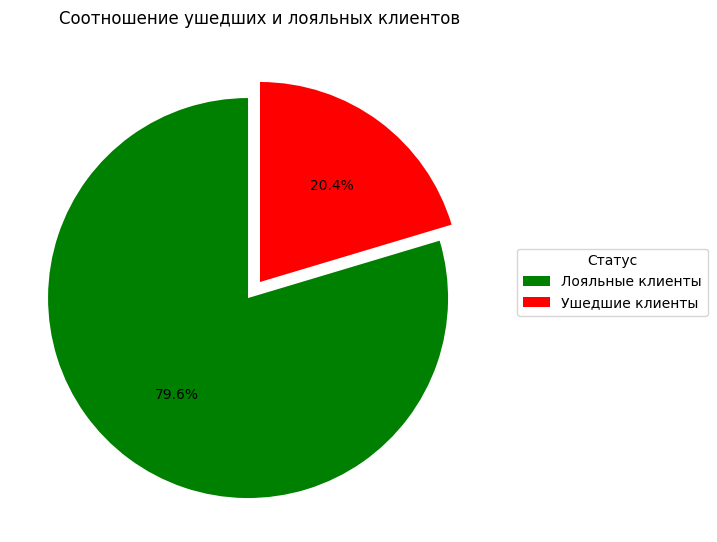

In [63]:
#9.1

#churn_data['Exited']

client_ex_status = churn_data['Exited'].value_counts()
display(client_ex_status)

fig = plt.figure(figsize=(5, 5));
axes = fig.add_axes([0, 0, 1, 1]);

axes.pie(
    client_ex_status,
    #labels = ['Лояльные клиенты', 'Ушедшие клиенты'], # с легендой читается лучше    
    colors=(['green', 'red']),    
    startangle=90,    
    autopct='%.1f%%',    
    explode = [0.1, 0]
);

axes.legend(['Лояльные клиенты', 'Ушедшие клиенты'],
          title="Статус",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1));

axes.set(title='Cоотношение ушедших и лояльных клиентов');


9.1. Каково соотношение ушедших и лояльных клиентов? Покажите это на графике и дайте комментарий по соотношению.

Ответ:
- Всего клиентов в базе = 10000
- Количество лояльных (Exited=0) клиентов 7963, что составляет 79,6%.
- Количество ушедших (Exited=1) клиентов = 2037, что составляет 20,4%.

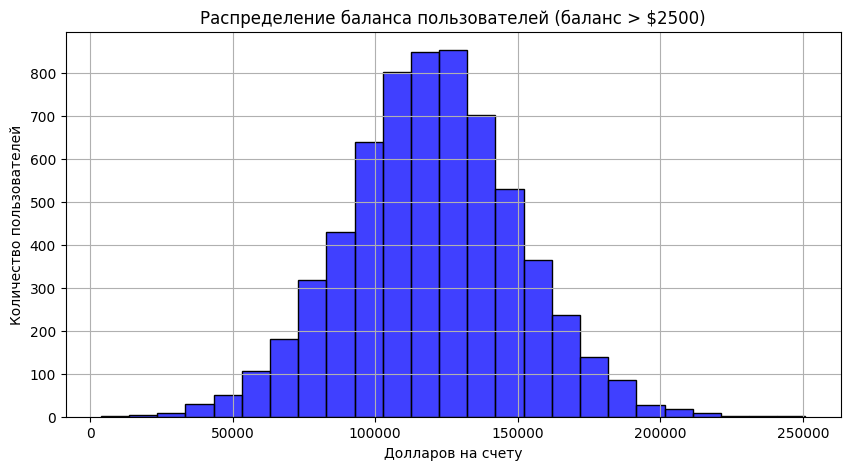

In [64]:
#9.2

#Построение графика histplot

filter_1 = churn_data['Balance'] > 2500

fig = plt.figure(figsize=(10, 5));
#axes = fig.add_axes([0, 0, 1, 1]); # не требуется

histplot = sns.histplot(
    data=churn_data[filter_1],
    x='Balance',
    bins=25,
    kde=False,
    color='blue'    
    #ax=axes # не требуется
);

histplot.set_title('Распределение баланса пользователей (баланс > $2500)', fontsize=12);
histplot.set_xlabel('Долларов на счету');
histplot.set_ylabel('Количество пользователей');
histplot.grid();

#Статистика и проверка
#filter_2 = (churn_data['Balance'] > 50000) & (churn_data['Balance'] < 200000)
#display(churn_data[filter_1].shape[0])
#display(churn_data[filter_2].shape[0])
#display(churn_data[filter_1]['Balance'].min())
#display(churn_data[filter_1]['Balance'].max())
#display(churn_data[filter_1]['Balance'].mean())
#display(churn_data[filter_1]['Balance'].sort_values())

9.2. Постройте график, показывающий распределение баланса пользователей, у которых на счету больше 2 500 долларов. Опишите распределение и сделайте выводы.

Ответ:
- Всего пользователей у которых на счету больше 2 500 долларов = 6383
- Пограничные значения: min 3768, max 250898, mean 119827.
- На графике видно, что основное количество отфильтрованных пользователей распределяется между значениями $50000 и $200000.
- Так же видно, что есть несколько групп по примерно 800 пользователей у которых на счету около 125000 долларов.

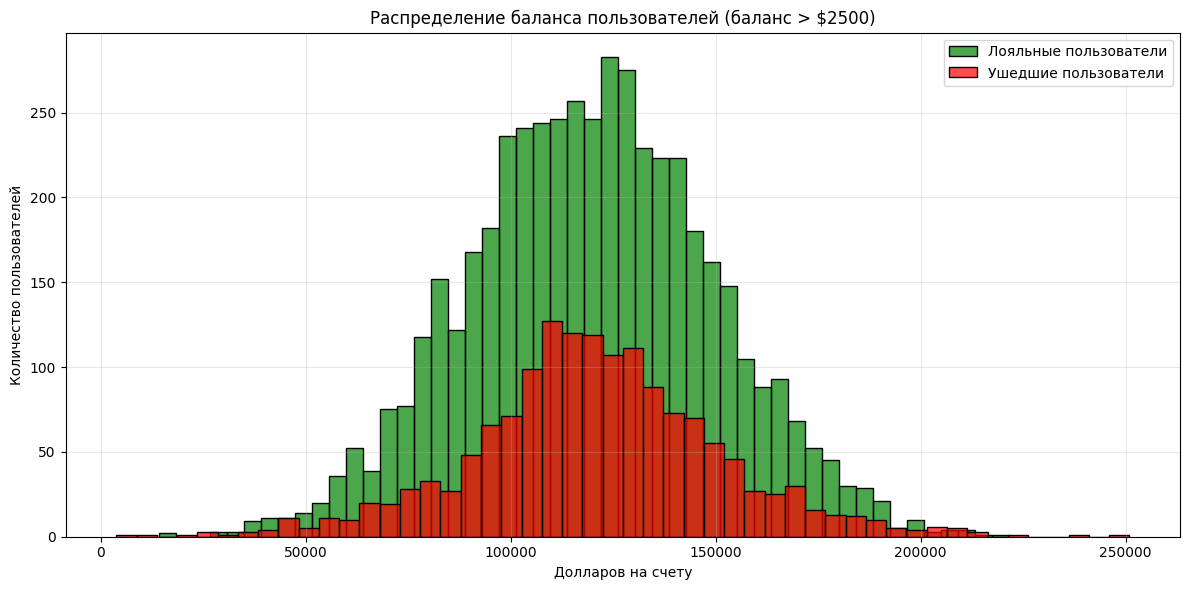

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_51108\3361133185.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  boxplot.set_yticklabels(['Лояльный', 'Ушедший'])


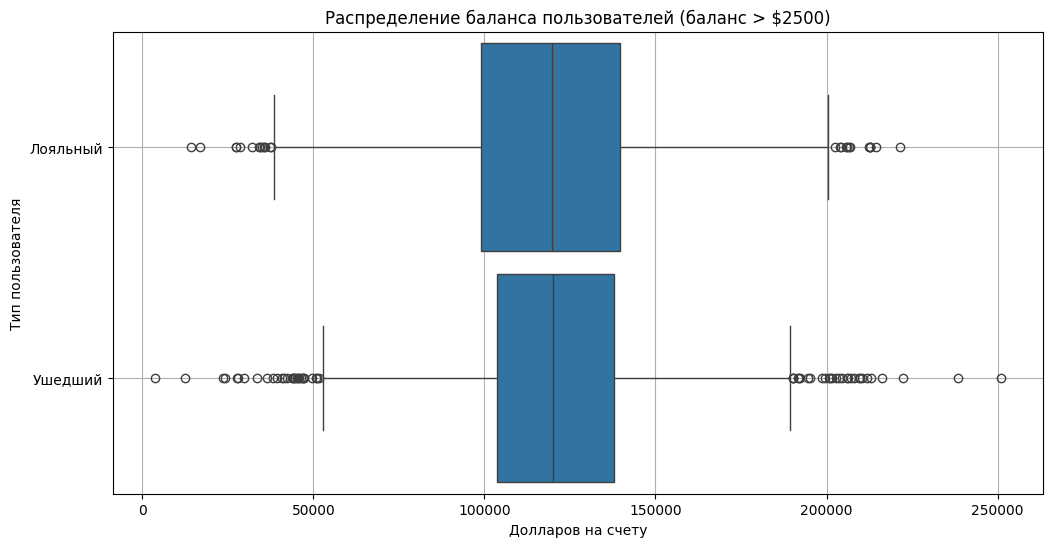

In [65]:
#9.3

#v2

# Фильтры
filter_loyal = churn_data['Exited'] == 0  # Лояльные пользователи
filter_lost = churn_data['Exited'] == 1   # Ушедшие пользователи
filter_balance = churn_data['Balance'] > 2500  # Баланс > 2500

loyal_data = churn_data[filter_loyal & filter_balance]
lost_data = churn_data[filter_lost & filter_balance]

# Построение графика histplot
plt.figure(figsize=(12, 6));

# Строим гистограммы для обоих сегментов на одном графике
sns.histplot(
    data=loyal_data,
    x='Balance',
    bins=50,
    kde=False,
    color='green',
    alpha=0.7,  # Прозрачность для наложения
    label='Лояльные пользователи'
);

sns.histplot(
    data=lost_data,
    x='Balance',
    bins=50,
    kde=False,
    color='red',
    alpha=0.7,
    label='Ушедшие пользователи'
);
# Настройка графика histplot
plt.title('Распределение баланса пользователей (баланс > $2500)', fontsize=12)
plt.xlabel('Долларов на счету')
plt.ylabel('Количество пользователей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Построение графика boxplot
plt.figure(figsize=(12, 6));
boxplot = sns.boxplot(
    data=churn_data[filter_balance],
    y='Exited',
    x='Balance',
    orient='h',
    width=0.9
);
boxplot.set_yticklabels(['Лояльный', 'Ушедший'])
boxplot.set_title('Распределение баланса пользователей (баланс > $2500)')
boxplot.set_xlabel('Долларов на счету')
boxplot.set_ylabel('Тип пользователя')
boxplot.grid()

'''
#v1
#(1 — ушедший клиент, 0 — лояльный клиент)
filter_loyal = churn_data['Exited'] == 0
filter_lost = churn_data['Exited'] == 1

# Строим гистограммы двух графиков в одной форме
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 12))

histplot_loyal = sns.histplot(
    data=churn_data[filter_loyal],
    x='Balance',
    bins=25,
    kde=True,
    color='blue',    
    ax=axes[0]
);
histplot_loyal.set_title('Распределение баланса лояльных пользователей')#, fontsize=10);
histplot_loyal.set_xlabel('Долларов на счету');
histplot_loyal.set_ylabel('Количество пользователей');
histplot_loyal.grid();

###
histplot_lost = sns.histplot(
    data=churn_data[filter_lost],
    x='Balance',
    bins=25,
    kde=True,
    color='blue',    
    ax=axes[1]
);
histplot_lost.set_title('Распределение баланса ушедших пользователей')#, fontsize=10);
histplot_lost.set_xlabel('Долларов на счету');
histplot_lost.set_ylabel('Количество пользователей');
histplot_lost.grid();
''';

9.3. Посмотрите на распределение баланса клиента в разрезе признака оттока. Как различаются суммы на накопительном счёте ушедших и лояльных клиентов? Подумайте и напишите, с чем это может быть связано, что может не устраивать ушедших клиентов в банке.

Ответ:
- Лояльные пользователи: распределение имеет выраженную пиковую область в диапазоне 110 000 – 130 000 долларов. 
- Ушедшие пользователи: пик распределения смещён влево, в область 100 000 – 110 000 долларов.
- В группе состоятельных клиентов с суммой больше 200 000 долларов на счете, ушедших клиентов больше чем лояльных. Их может не устраивать что угодно, например низкая процентная ставка по вкладам. При больших суммах даже десятые процента играют большую роль.

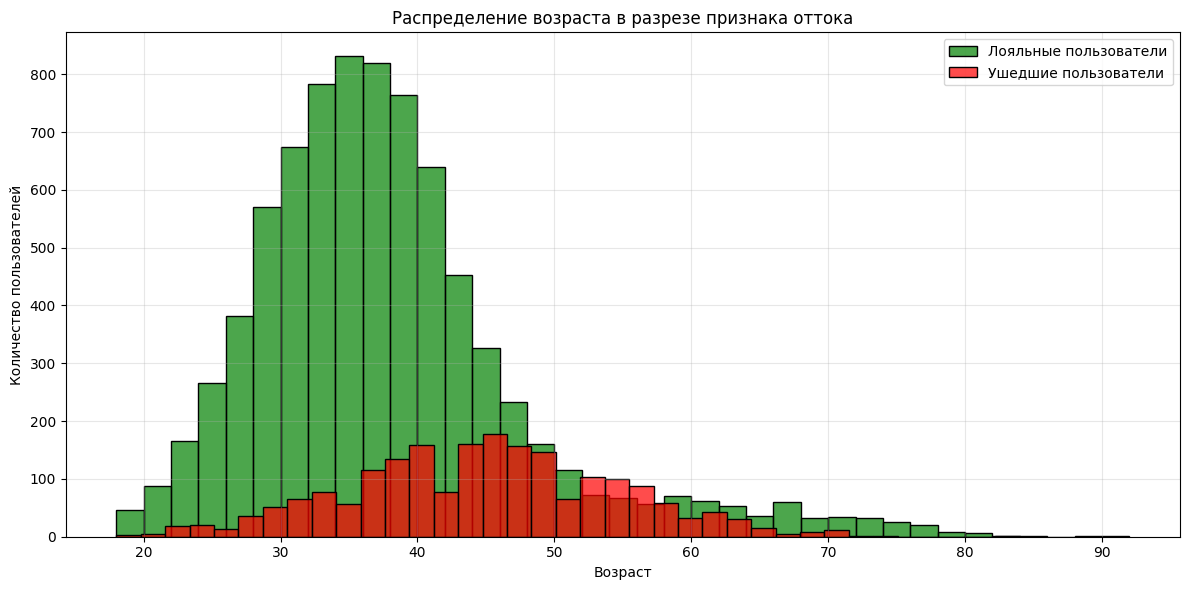

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_51108\4116189862.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  boxplot.set_yticklabels(['Лояльный', 'Ушедший'])


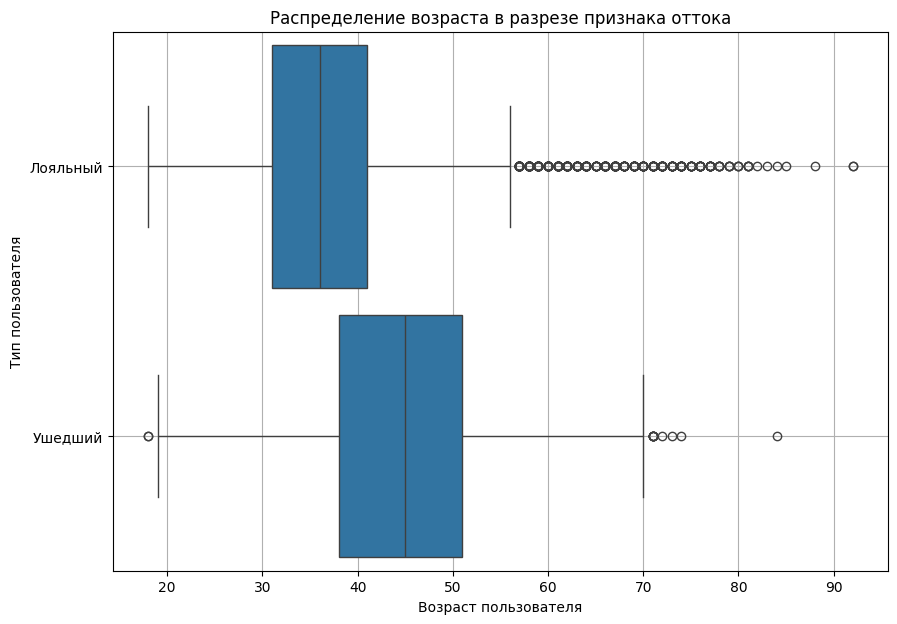

In [66]:
#9.4

# Построение графика histplot

# Фильтры
filter_loyal = churn_data['Exited'] == 0  # Лояльные пользователи
filter_lost = churn_data['Exited'] == 1   # Ушедшие пользователи
loyal_data = churn_data[filter_loyal]
lost_data = churn_data[filter_lost]

# Построение графика
plt.figure(figsize=(12, 6))

# Строим гистограммы для обоих сегментов на одном графике
sns.histplot(
    data=loyal_data,
    x='Age',
    bins=37,
    kde=False,
    color='green',
    alpha=0.7,  # Прозрачность для наложения
    label='Лояльные пользователи'
)
sns.histplot(
    data=lost_data,
    x='Age',
    bins=37,
    kde=False,
    color='red',
    alpha=0.7,
    label='Ушедшие пользователи'
)
# Настройка графика
plt.title('Распределение возраста в разрезе признака оттока', fontsize=12)
plt.xlabel('Возраст')
plt.ylabel('Количество пользователей')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Построение графика boxplot

plt.figure(figsize=(10, 7))
boxplot = sns.boxplot(
    data=churn_data,
    y='Exited',
    x='Age',
    orient='h',
    width=0.9
)
# Настройка графика
boxplot.set_yticklabels(['Лояльный', 'Ушедший'])
boxplot.set_title('Распределение возраста в разрезе признака оттока');
boxplot.set_xlabel('Возраст пользователя');
boxplot.set_ylabel('Тип пользователя');
boxplot.grid()

9.4. Посмотрите на распределение возраста в разрезе признака оттока. В какой группе больше потенциальных выбросов? На какую возрастную категорию клиентов стоит обратить внимание банку?

Ответ:
- Ушедшие пользователи старше лояльных. Медианный возраст лояльных 35 лет, ушедших 45 лет.
- Выбросов больше в группе лояльных пользователей.
- Банку необходимо обратить внимание на возрастную группу 40+

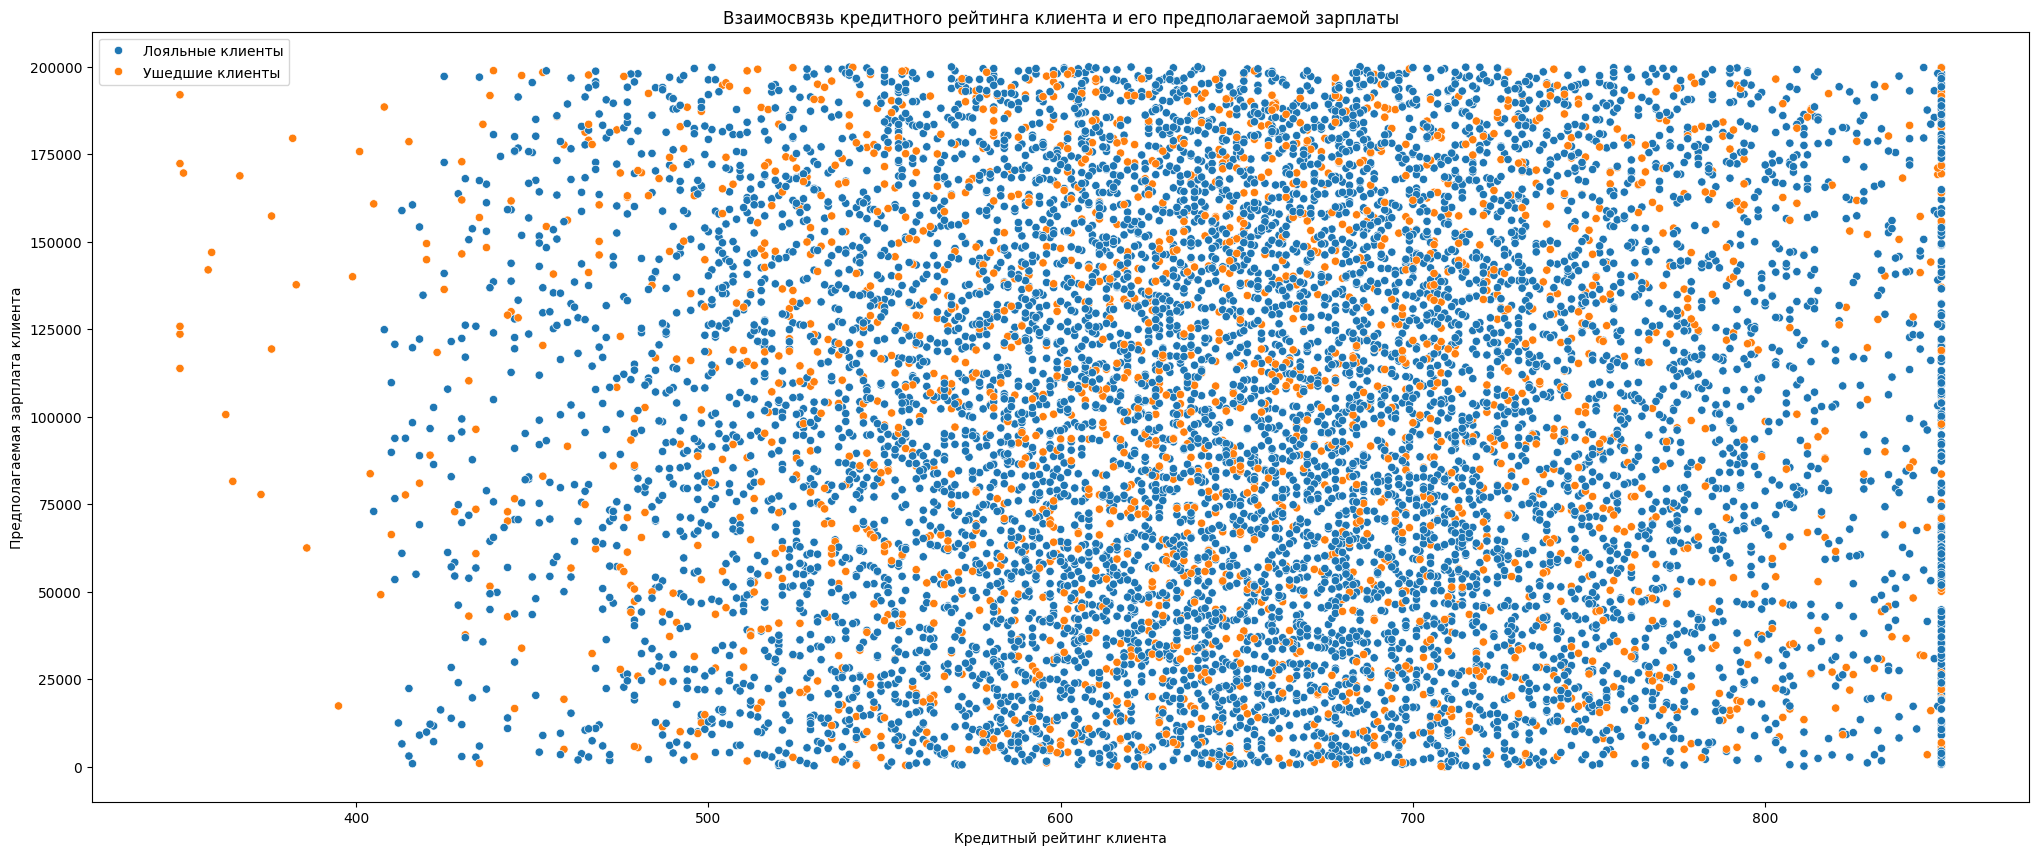

In [67]:
#9.5

#display(churn_data['CreditScore'].value_counts())
#display(churn_data['CreditScore'].max())

# Построение графика scatterplot
fig = plt.figure(figsize=(25, 10))
scatterplot = sns.scatterplot(
    data=churn_data,
    x='CreditScore',
    y='EstimatedSalary',
    hue='Exited'
);

scatterplot.set_title('Взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты', fontsize=12)
scatterplot.set_xlabel('Кредитный рейтинг клиента')
scatterplot.set_ylabel('Предполагаемая зарплата клиента')

#legend 
# Не очень понятно как это работает, но работает
handles, labels = scatterplot.get_legend_handles_labels();
scatterplot.legend(title='Тип пользователя');
scatterplot.legend(handles, ['Лояльные клиенты', 'Ушедшие клиенты']);



9.5. Постройте график, который показывает взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты. Добавьте расцветку по признаку оттока клиентов. Какова взаимосвязь между признаками? Если не видите явной взаимосвязи, укажите это.

Ответ:
- Между кредитным рейтингом и предполагаемой зарплатой связи на графике не прослеживается.
- Кредитный рейтинг 850 является максимальным. Этот рейтинг присвоен большому, в соотношении с другими, количеству клинтов: 233. Это видно и на графике в виде "столба" точек. 

Gender
Female    1139
Male       898
Name: count, dtype: int64

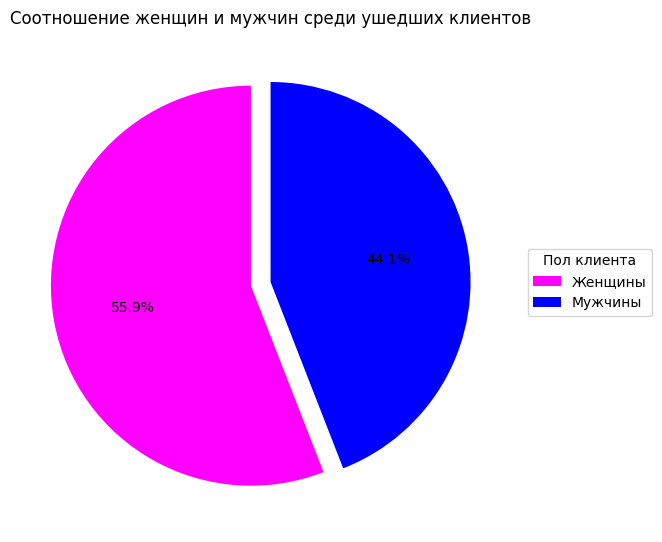

In [68]:
#9.6

# Фильтры
filter_loyal = churn_data['Exited'] == 0  # Лояльные пользователи
filter_lost = churn_data['Exited'] == 1   # Ушедшие пользователи

#Статистика в цифрах
#display(churn_data.groupby('Gender')['Exited'].mean()) 
display(churn_data[filter_lost]['Gender'].value_counts())
#display(churn_data[filter_loyal]['Gender'].value_counts())
#print(1139*100/10000)
#print(898*100/10000)

#Создание графика pie
fig = plt.figure(figsize=(5, 5));
axes = fig.add_axes([0, 0, 1, 1]);

axes.pie(
    churn_data[filter_lost]['Gender'].value_counts(),
    #labels = ['Лояльные клиенты', 'Ушедшие клиенты'], # с легендой читается лучше    
    colors=(['magenta', 'blue']),    
    startangle=90,    
    autopct='%.1f%%',    
    explode = [0.1, 0]
);
axes.legend(['Женщины', 'Мужчины'],
          title="Пол клиента",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1));
axes.set(title='Cоотношение женщин и мужчин среди ушедших клиентов');

9.6. Кто чаще уходит, мужчины или женщины? Постройте график, который иллюстрирует это.

*Подсказка: Процент ушедших клиентов в каждой группе можно рассчитать как среднее по столбцу Exited (так как 1 — это ушедшие клиенты, а 0 — лояльные, среднее арифметическое по столбцу обозначает долю ушедших клиентов).*

Ответ:
- Чаще уходят женщины. Среди ушедших 1139 (55.9%) женщин и 898 (44.1%) мужчин.
- В соотношении от общего количества клиентов женщин ушло 11.39%, мужчин 8,98%.

Exited,Лояльные клиенты,Ушедшие клиенты
NumOfProducts,,
1,3675,1409
2,4242,348
3,46,220
4,0,60


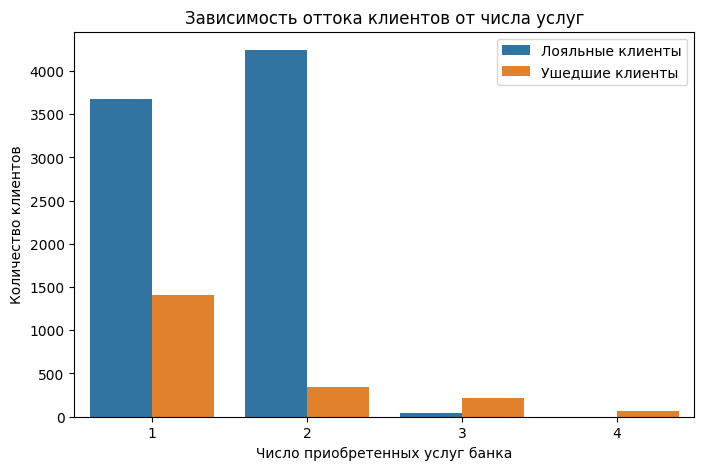

In [69]:
#9.7

#Данные в цифрах

#display(churn_data['NumOfProducts'].describe())
#display(churn_data['NumOfProducts'])
#display(churn_data)

# Подготавливаем сводную таблицу
pivot_table = churn_data.pivot_table(
    values='CustomerId',    #имя столбца, по которому необходимо получить сводные данные, применяя агрегирующую функцию
    index='NumOfProducts',  #имя столбца, значения которого станут строками сводной таблицы
    columns='Exited',       #имя столбца, значения которого станут столбцами сводной таблицы
    fill_value=0,
    aggfunc='count'
)
#Делаем сразу осмысленные имена столбцов
pivot_table.rename(columns={0: 'Лояльные клиенты', 1: 'Ушедшие клиенты'}, inplace=True)

#Выводим данные
display(pivot_table)

# Строим многоуровневую столбчатую диаграмму countplot
fig = plt.figure(figsize=(8, 5))
countplot = sns.countplot(
    data=churn_data,    
    x='NumOfProducts',
    hue='Exited'
)
#Настройка графика
countplot.set_title('Зависимость оттока клиентов от числа услуг');
countplot.set_xlabel('Число приобретенных услуг банка');
countplot.set_ylabel('Количество клиентов');
#legend # Не очень понятно как это работает, но работает
handles, labels = countplot.get_legend_handles_labels();
countplot.legend(title='Тип пользователя');
countplot.legend(handles, ['Лояльные клиенты', 'Ушедшие клиенты']);

9.7. Как отток клиентов зависит от числа приобретённых у банка услуг? Для ответа на этот вопрос постройте многоуровневую столбчатую диаграмму.

Ответ:
- В каждой категории приобретенных услуг уесть ушедшие клиенты. 
- Отток клиентов уменьшается с увеличением количества приобретенных услуг.